In [6]:
import torch
from torch import nn, optim
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from math import isqrt

In [7]:
from model import get_pos_embeddings, NetCheckpoint

In [ ]:
# IMage
D_IMAGE = 96
N_CHANNELS = 3
PATCH_SIZE = 8
D_patch = (PATCH_SIZE**2) * N_CHANNELS # 192
N_PATCHES = (D_IMAGE**2) // (PATCH_SIZE**2) # 144
N_ROWS = D_IMAGE // PATCH_SIZE

# Encoder
D = 384
N_HEADS_DEC = 6
D_mlp = 4*D

# Decoder
# Normally D_decoder = D//2 but ViT-Tiny is already so shallow, and I can reuse
# positional embeddings for encoder/decoder if they're the same dim
D_decoder = D // 2
D_decoder_mlp = 4*D_decoder
N_HEADS_DEC = 3

BATCH_SIZE = 512

PERCENT_UNMASKED = 0.25

In [9]:
# Transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4467, 0.4398, 0.4066), (0.2603, 0.2566, 0.2713))
])

In [10]:
# Download and load datasets
supervised_trainset = torchvision.datasets.STL10(
    root='./data', split='train', download=True, transform=transform
)
testset = torchvision.datasets.STL10(
    root='./data', split='test', download=True, transform=transform
)
unlabeled_set = torchvision.datasets.STL10(
    root='./data', split='unlabeled', download=True, transform=transform
)

In [11]:
# DataLoaders
supervised_trainloader = torch.utils.data.DataLoader(
    supervised_trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2
)
ssl_trainloader = torch.utils.data.DataLoader(
    unlabeled_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2
)

In [12]:
device = torch.device('cuda:0')

In [ ]:
pos_embeddings_enc = get_pos_embeddings(D, N_PATCHES, N_ROWS, device)
pos_embeddings_dec = get_pos_embeddings(D_decoder, N_PATCHES, N_ROWS, device)

net = NetCheckpoint(
    n_encoder_blocks=12,
    n_decoder_blocks=4,
    d_image=D_IMAGE,
    patch_size=PATCH_SIZE,
    d_patch=D_patch,
    n_patches=N_PATCHES,
    n_rows=N_ROWS,
    d_enc=D,
    D_mlp=D_mlp,
    D_decoder=D_decoder,
    D_decoder_mlp=D_decoder_mlp,
    n_heads=N_HEADS_ENC,
    pos_embeddings_enc=pos_embeddings_enc,
    pos_embedding_dec=pos_embeddings_dec,
    percent_unmasked=PERCENT_UNMASKED)
checkpoint = torch.load('checkpoints/checkpoint_epoch_340.pt')
net.load_state_dict(checkpoint['model_state_dict'])
net.to(device)

NetCheckpoint(
  (img2enc_projection): Linear(in_features=192, out_features=384, bias=True)
  (encoder_blocks): ModuleList(
    (0-11): 12 x ModuleDict(
      (norm_a): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (msa): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
      )
      (norm_b): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (mlp_a): Linear(in_features=384, out_features=1536, bias=True)
      (mlp_b): Linear(in_features=1536, out_features=384, bias=True)
    )
  )
  (enc2dec_projection): Linear(in_features=384, out_features=192, bias=True)
  (decoder_blocks): ModuleList(
    (0-3): 4 x ModuleDict(
      (norm_a): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (msa): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=192, out_features=192, bias=True)
      )
      (norm_b): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
     

In [16]:
def patches_to_images(patches):
    # (B, patches, D_patch)
    B, SEQ, D_patch_local = patches.shape
    x = patches.view(B, N_ROWS, N_ROWS, D_patch_local)
    x = x.view(B, N_ROWS, N_ROWS, N_CHANNELS, PATCH_SIZE, PATCH_SIZE)
    x = x.permute(0, 3, 1, 4, 2, 5).contiguous()
    x = x.view(B, N_CHANNELS, N_ROWS * PATCH_SIZE, N_ROWS * PATCH_SIZE)
    return x
    

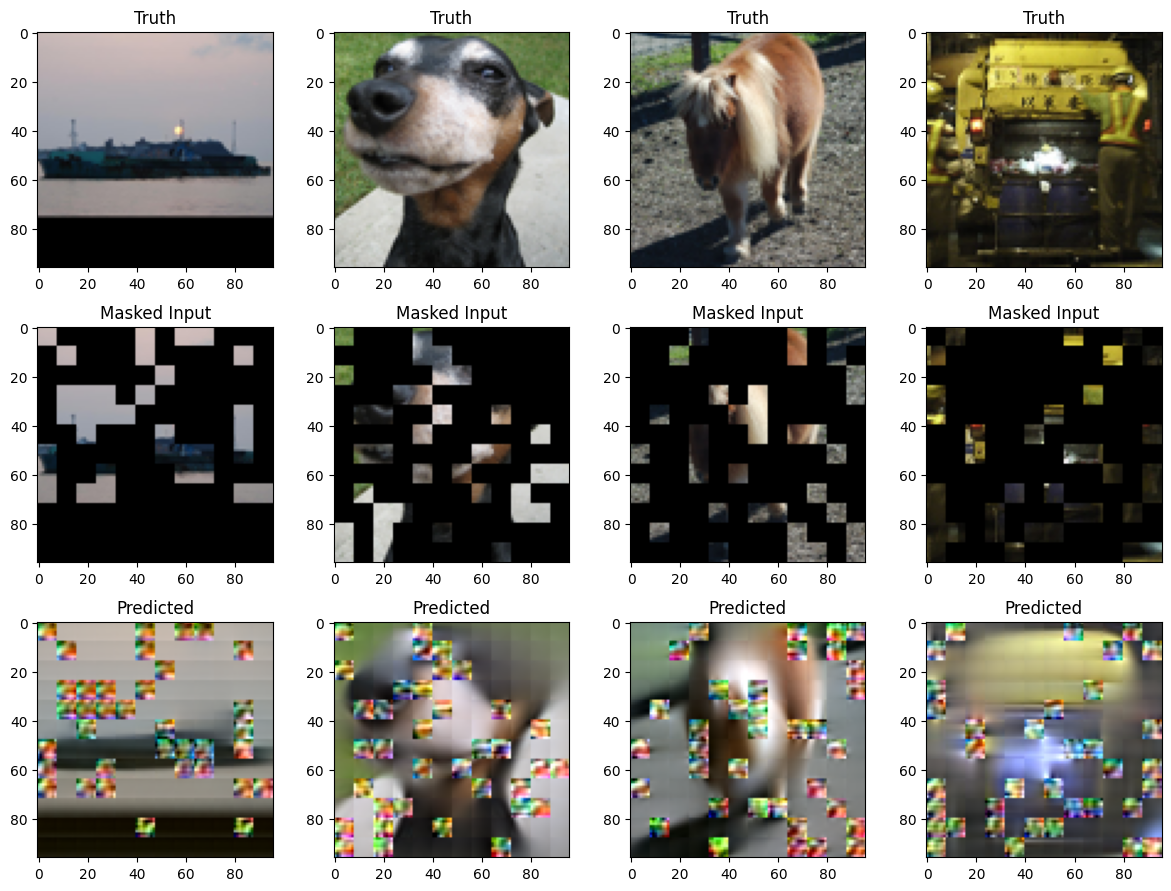

In [17]:
mean = torch.tensor([0.4467, 0.4398, 0.4066]).view(1, 3, 1, 1)
std = torch.tensor([0.2603, 0.2566, 0.2713]).view(1, 3, 1, 1)

def show_masked_image(image, ids_masked, b):
    image = image.clone()
    masked = ids_masked[b]
    for patch_idx in masked:
        row = patch_idx // N_ROWS
        col = patch_idx % N_ROWS
        image[:, row*PATCH_SIZE:(row+1)*PATCH_SIZE, col*PATCH_SIZE:(col+1)*PATCH_SIZE] = 0
    return image

with torch.no_grad():
    for i, data in enumerate(supervised_trainloader):
        inputs, labels = data[0].to(device), data[1]
        y_pred_patches, y_true_patches, ids_masked = net(inputs)
        
        pred_images = (patches_to_images(y_pred_patches).cpu() * std + mean).clip(0, 1)
        true_images = (inputs.cpu() * std + mean).clip(0, 1)
        
        masked_images = torch.stack([show_masked_image(true_images[j], ids_masked.cpu(), j) for j in range(4)])
        
        fig, axes = plt.subplots(3, 4, figsize=(12, 9))
        for j in range(4):
            axes[0, j].imshow(true_images[j].permute(1, 2, 0))
            axes[0, j].set_title('Truth')
            axes[1, j].imshow(masked_images[j].permute(1, 2, 0))
            axes[1, j].set_title('Masked Input')
            axes[2, j].imshow(pred_images[j].permute(1, 2, 0))
            axes[2, j].set_title('Predicted')
        plt.tight_layout()
        plt.show()
        break